[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/planetlabs/notebooks/blob/master/jupyter-notebooks/workflows/superres_scenes/planetscope_superres_scenes.ipynb)

# Planet SuperRes on PlanetScope Scenes

This notebook demonstrates how to use **Planet SuperRes** to enhance PlanetScope imagery from its 3 meter pixel size and 3.7 meter ground sample distance to a 2 meter pixel size super resolved prediction. SuperRes applies a supervised deep learning model via the [Processing API](https://docs.planet.com/develop/apis/processing/). The model takes PlanetScope Surface Reflectance (SR) data as input and returns enhanced-resolution imagery along with a per-pixel confidence layer.

**What you will learn:**
- How to fetch standard PlanetScope imagery at native 3 m pixel size
- How to apply the SuperRes model to the PlanetScope imagery with the Processing API

## Set up Environment

In [1]:
# If necessary, uncomment the following line and run this cell to install required packages (for example, if you are using Colab).
# %pip install -q sentinelhub --quiet

In [2]:
import numpy as np
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from sentinelhub import (
    DataCollection,
    MimeType,
    MosaickingOrder,
    ResamplingType,
    SentinelHubRequest,
    BBox,
    CRS,
    get_utm_crs,
)

### Authentication

This notebook uses the Sentinel Hub Python SDK. This SDK requires a `client_id` and a `client_secret`. To obtain your `client_id` & `client_secret`, you need to navigate to your [account](https://insights.planet.com/account/), and go to **User Settings**. From there you can create a new OAuth client. More detailed instructions can be found in our [authentication documentation](https://docs.planet.com/develop/authentication/).

Once you have your `client_id` & `client_secret`, it is recommended to configure a new profile in your Sentinel Hub Python package. Instructions on how to configure your Sentinel Hub Python package can be found [in the documentation](https://sentinelhub-py.readthedocs.io/en/latest/configure.html). This is useful as changes to the config class in your notebook are usually only temporary and by saving the configuration to your profile, you don't have to generate new credentials or overwrite the default profile every time you run a new Jupyter Notebook.

The following cell checks for an existing default configuration. If none is found, you will be prompted for your credentials, which you can then optionally save.

In [ ]:
from sentinelhub import SHConfig

# Authenticate with the Sentinel Hub Python SDK; See docs: https://sentinelhub-py.readthedocs.io/en/latest/configure.html and https://docs.planet.com/develop/authentication
# If no default configuration detected, enter a client ID and secret to authenticate. These can be obtained by creating an OAuth client here: https://insights.planet.com/account
config = SHConfig()
if not config.sh_client_id or not config.sh_client_secret:
    from getpass import getpass

    print("No credentials found, please provide the OAuth client ID and secret.")
    config.sh_client_id = getpass("Client ID: ")
    config.sh_client_secret = getpass("Client Secret: ")
    ## Uncomment the following lines to save your credentials to a configuration
    # config.save()
    # print(f'Credentials saved to {SHConfig.get_config_location()}')
else:
    print(f"Using credentials stored here: {SHConfig.get_config_location()}")

## Request Standard (3 m/px) PlanetScope

We define a small AOI in **WGS84** and convert its extent to a **UTM bounding box** in meters. Working in UTM keeps the area of interest in a local projected CRS so we can sample a regular grid in with a precise meters per pixel rather than in geographic degrees.

The cell prints footprint size in **km** and **`standard_shape_px`**: image width and height in pixels by dividing each side of the UTM bbox by **3** and rounding. That is the **~3 m** pixel grid used for the standard PlanetScope request.

> **Minimum AOI size:** Super Resolution requires an AOI of at least **0.5 km²**.

In [4]:
# AOI (WGS84) to UTM bbox (m) to raster size at nominal ~3 m pixel size
aoi_coords = [
    [
        [31.455, 30.045],
        [31.473, 30.045],
        [31.473, 30.060],
        [31.455, 30.060],
        [31.455, 30.045],
    ]
]
aoi_gdf = gpd.GeoDataFrame(
    index=[0],
    crs="EPSG:4326",
    geometry=[shape({"type": "Polygon", "coordinates": aoi_coords})],
)

bounds_wgs84 = aoi_gdf.total_bounds  # min_lon, min_lat, max_lon, max_lat
lon0, lat0, lon1, lat1 = bounds_wgs84
utm_crs = get_utm_crs((lon0 + lon1) / 2, (lat0 + lat1) / 2)

utm_bbox = BBox(bounds_wgs84.tolist(), crs=CRS.WGS84).transform(utm_crs)
min_x, min_y, max_x, max_y = utm_bbox

width_m, height_m = max_x - min_x, max_y - min_y
NATIVE_PIXEL_SIZE_M = 3  # PlanetScope pixel size for standard_shape_px in this workflow
standard_shape_px = (
    round(width_m / NATIVE_PIXEL_SIZE_M),
    round(height_m / NATIVE_PIXEL_SIZE_M),
)

print(
    f"UTM CRS: {utm_crs}\n"
    f"Extent: {width_m / 1000:.3f} km (E-W) x {height_m / 1000:.3f} km (N-S)\n"
    f"Target @ ~{NATIVE_PIXEL_SIZE_M} m: {standard_shape_px[0]} x {standard_shape_px[1]} px"
)

UTM CRS: EPSG:32636
Extent: 1.758 km (E-W) x 1.639 km (N-S)
Target @ ~3 m: 586 x 546 px


This step uses PlanetScope data from **[Planet Sandbox Data](https://docs.planet.com/data/imagery/planetscope/sandbox/)**. For this walkthrough, the data is already available in a **data collection** and the `COLLECTION` UUID passed to `define_byoc`.

For **your own** area and time of interest, you will need to **deliver imagery into a data collection** using Planet **Orders** or **Subscriptions** (via the **APIs** or the **insights.planet.com**), then point at that collection instead of the sandbox ID. The request below is otherwise the same pattern: Process API over `utm_bbox` at `standard_shape_px` (~**3 m pixel spacing**), with an inline evalscript that scales values for a quick on-screen preview.

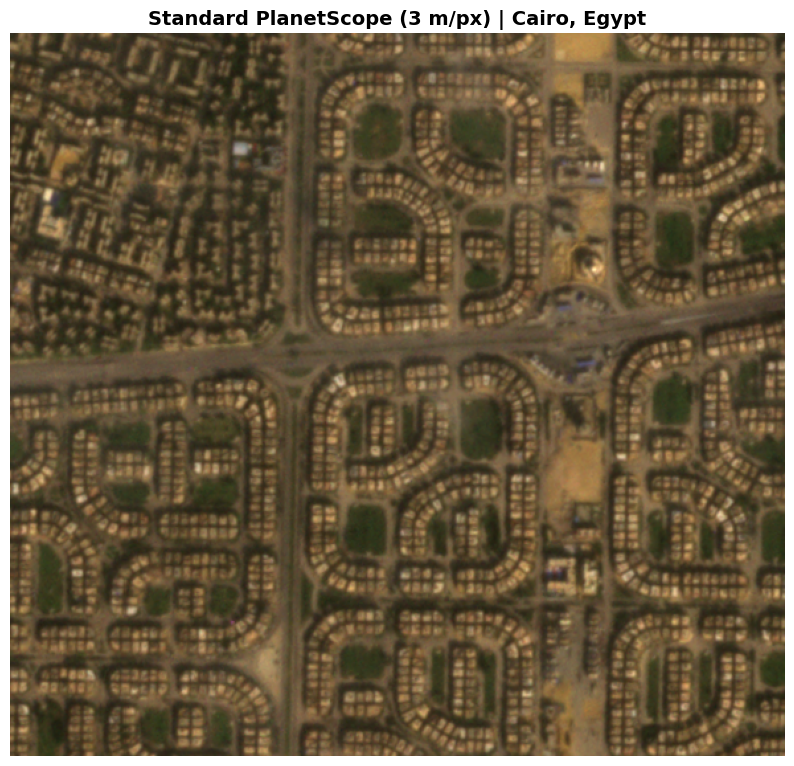

In [5]:
COLLECTION = (
    "28eef896-9632-4546-a99e-cea34d74b21e"  # PlanetScope SR 8-band (sandbox data)
)
DATE = "2023-12-30"

evalscript = """
//VERSION=3
function setup() { return { input: ["red", "green", "blue", "dataMask"], output: { bands: 4 } }; }
function evaluatePixel(s) { return [s.red/4000, s.green/4000, s.blue/4000, s.dataMask]; }  // scale SR reflectance (~0-10000) to ~0-1 for display
"""

request = SentinelHubRequest(
    evalscript=evalscript,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.define_byoc(COLLECTION),
            time_interval=(f"{DATE}T00:00:00Z", f"{DATE}T23:59:59Z"),
        )
    ],
    responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
    bbox=utm_bbox,
    size=standard_shape_px,
    config=config,
)

standard_planet_scope = request.get_data()[0]

fig, ax = plt.subplots(figsize=(10, 10))
img_extent = [min_x, max_x, min_y, max_y]
ax.imshow(standard_planet_scope, extent=img_extent, origin="upper")
ax.set_title(
    "Standard PlanetScope (3 m/px) | Cairo, Egypt", fontsize=14, fontweight="bold"
)
ax.set_axis_off()
plt.show()

## Request SuperRes (2 m/px) PlanetScope

SuperRes is requested over the **same geographic extent** (`utm_bbox`) as the standard PlanetScope step. Finer **pixel spacing** (2 m along each axis instead of 3 m) means **more columns and rows** are needed to cover the same ground width and height. Pixel counts scale roughly as **3/2** compared to `standard_shape_px`, because you divide the same `width_m` and `height_m` by a smaller metres-per-pixel value. The next cell computes **`superres_shape_px`** only. It reuses the corners already unpacked from `utm_bbox`.

In [6]:
# SuperRes: same utm_bbox as standard PlanetScope, but superres_shape_px uses a finer
# pixel spacing (RES_OUT_M = 2 m). Same metres / smaller metres-per-pixel => more pixels.

RES_OUT_M = 2  # nominal SuperRes output pixel size (m) for this workflow
superres_shape_px = (round(width_m / RES_OUT_M), round(height_m / RES_OUT_M))

print(f"Extent (unchanged): {width_m / 1000:.3f} km x {height_m / 1000:.3f} km")
print(
    f"Standard @ ~3 m: {standard_shape_px[0]} x {standard_shape_px[1]} px | SuperRes @ ~2 m: {superres_shape_px[0]} x {superres_shape_px[1]} px"
)


Extent (unchanged): 1.758 km x 1.639 km
Standard @ ~3 m: 586 x 546 px | SuperRes @ ~2 m: 879 x 820 px


The SuperRes model is invoked by referencing an **evalscript ID** for an evalscript that is hosted on Planet Insights Platform, rather than an inline evalscript as we used in the standard request. Additional model parameters (`buffer` and `blockSize`) are passed via `evalscriptParams`.

The response returns dictionary with 6 keys each representing a band:
- **`blue.tif`** — super-resolved blue reflectance
- **`green.tif`** — super-resolved green reflectance
- **`red.tif`** — super-resolved red reflectance
- **`nir.tif`** — super-resolved near-infrared (Note: Near-infrared is provided, but has not yet been rigorously validated as part of the SuperRes model outputs. This band should be used with extra caution.)
- **`confidence.tif`** — per-pixel confidence score (0–100)
- **`dataMask.tif`** — data mask

In [7]:
# Define SuperRes evalscriptParams
SUPERRES_EVAL_ID = "aeb5784f-17ac-48de-b091-7c4fe3708ee5:2"
SUPERRES_PARAMS = {"buffer": 10, "blockSize": 236}  # 236 + 2x10 = 256

superres_request = SentinelHubRequest(
    evalscript=SUPERRES_EVAL_ID,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.define_byoc(COLLECTION),
            time_interval=(f"{DATE}T00:00:00Z", f"{DATE}T23:59:59Z"),
            mosaicking_order=MosaickingOrder.MOST_RECENT,
            upsampling=ResamplingType.BILINEAR,
        )
    ],
    responses=[
        SentinelHubRequest.output_response("red", MimeType.TIFF),
        SentinelHubRequest.output_response("green", MimeType.TIFF),
        SentinelHubRequest.output_response("blue", MimeType.TIFF),
        SentinelHubRequest.output_response("nir", MimeType.TIFF),
        SentinelHubRequest.output_response("dataMask", MimeType.TIFF),
        SentinelHubRequest.output_response("confidence", MimeType.TIFF),
    ],
    bbox=utm_bbox,
    size=superres_shape_px,
    config=config,
)

# To use the special SuperRes parameters, we mutate the SDK-generated payload because the SDK currently doesn't support this natively.
superres_request.payload["evalscriptParams"] = SUPERRES_PARAMS

print(f"Fetching SuperRes ({superres_shape_px[0]}×{superres_shape_px[1]} px @ ~2 m)...")
super_res_planet_scope = superres_request.get_data()[0]
print(f"Received SuperRes dict with keys: {super_res_planet_scope.keys()}")
print(
    f"Each key contains array of shape: {super_res_planet_scope[list(super_res_planet_scope.keys())[0]].shape}"
)

Fetching SuperRes (879×820 px @ ~2 m)...
Received SuperRes dict with keys: dict_keys(['red.tif', 'green.tif', 'blue.tif', 'nir.tif', 'dataMask.tif', 'confidence.tif'])
Each key contains array of shape: (820, 879)


SuperRes returns six bands — blue, green, red, NIR, confidence, and dataMask — with surface reflectance values in the `0–10000` range. To display as an RGB image, we stack the red, green, and blue bands in that order, then divide by `4000` and clip to 0–1 so imshow renders a properly exposed color image.

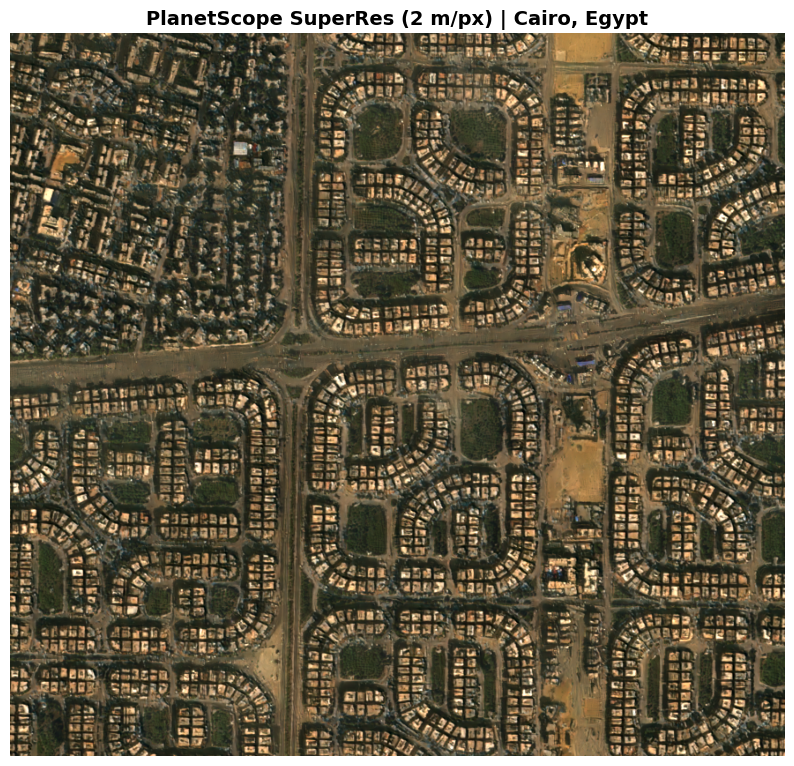

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
img_extent = [min_x, max_x, min_y, max_y]
rgb = np.stack(
    [
        super_res_planet_scope["red.tif"],
        super_res_planet_scope["green.tif"],
        super_res_planet_scope["blue.tif"],
    ],
    axis=-1,
)
super_res_planet_scope_RGB = np.clip(rgb / 4000, 0, 1)
ax.imshow(super_res_planet_scope_RGB, extent=img_extent, origin="upper")
ax.set_title(
    "PlanetScope SuperRes (2 m/px) | Cairo, Egypt", fontsize=14, fontweight="bold"
)
ax.set_axis_off()
plt.show()

## Compare Standard PlanetScope with SuperRes

Now, we can plot the imagery over three panels: native **3 m/px** PlanetScope, **2 m/px** SuperRes, and the SuperRes **confidence** layer (0–100).

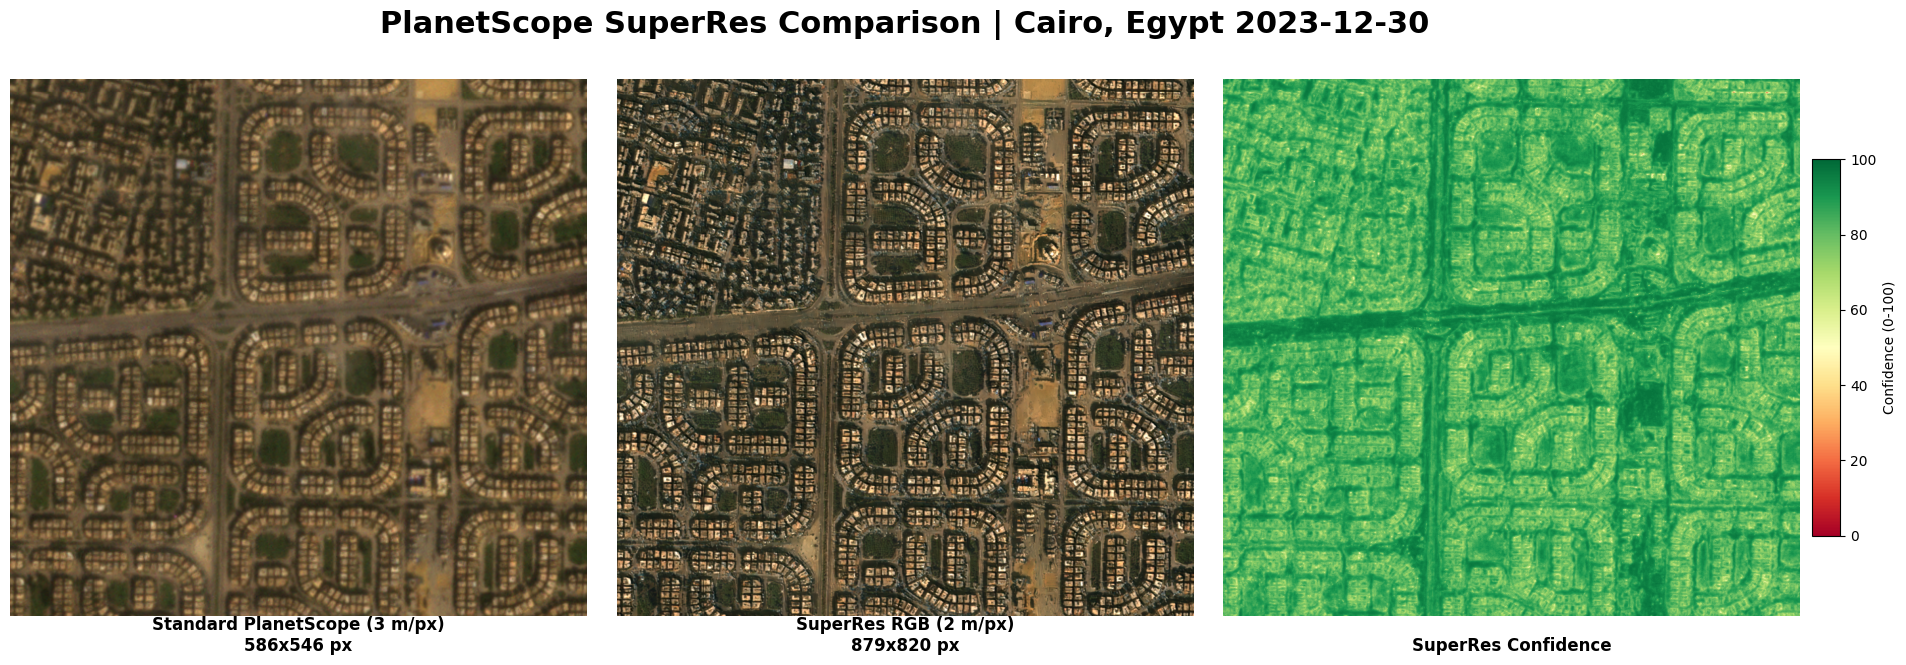

In [9]:
# Shared map extent (same utm_bbox as all Processing API requests in this notebook)
img_extent = [min_x, max_x, min_y, max_y]
CONFIDENCE_BAND = "confidence.tif"

fig, axes = plt.subplots(1, 3, figsize=(18, 7.5), layout="constrained")
fig.set_constrained_layout_pads(w_pad=0.05, h_pad=0.02, hspace=0, wspace=0.05)

# --- Standard PlanetScope (3 m/px); evalscript already scales RGB for display
axes[0].imshow(standard_planet_scope, extent=img_extent, origin="upper")
axes[0].set_title(
    f"Standard PlanetScope (3 m/px)\n{standard_planet_scope.shape[1]}x{standard_planet_scope.shape[0]} px",
    fontweight="bold",
    y=-0.08,
)

# --- SuperRes RGB (2 m/px); super_res_planet_scopeRGB from prior cell (RGB, /4000, clip)
axes[1].imshow(super_res_planet_scope_RGB, extent=img_extent, origin="upper")
axes[1].set_title(
    f"SuperRes RGB (2 m/px)\n{super_res_planet_scope_RGB.shape[1]}x{super_res_planet_scope_RGB.shape[0]} px",
    fontweight="bold",
    y=-0.08,
)

# --- SuperRes confidence (0–100), same geographic extent
im = axes[2].imshow(
    super_res_planet_scope[CONFIDENCE_BAND],
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    extent=img_extent,
    origin="upper",
)
axes[2].set_title("SuperRes Confidence", fontweight="bold", y=-0.08)

ax_ins = inset_axes(
    axes[2],
    width="5%",
    height="70%",
    loc="center left",
    bbox_to_anchor=(1.02, 0.0, 1, 1),
    bbox_transform=axes[2].transAxes,
    borderpad=0,
)
fig.colorbar(im, cax=ax_ins, label="Confidence (0-100)")

for ax in axes:
    ax.axis("off")
    ax.set_aspect("equal")

fig.suptitle(
    f"PlanetScope SuperRes Comparison | Cairo, Egypt {DATE}",
    fontsize=22,
    fontweight="bold",
    y=0.95,
)
plt.show()

### Zoomed Comparison

For an up close look at the difference, we can zoom into a few locations within the larger area of interest.

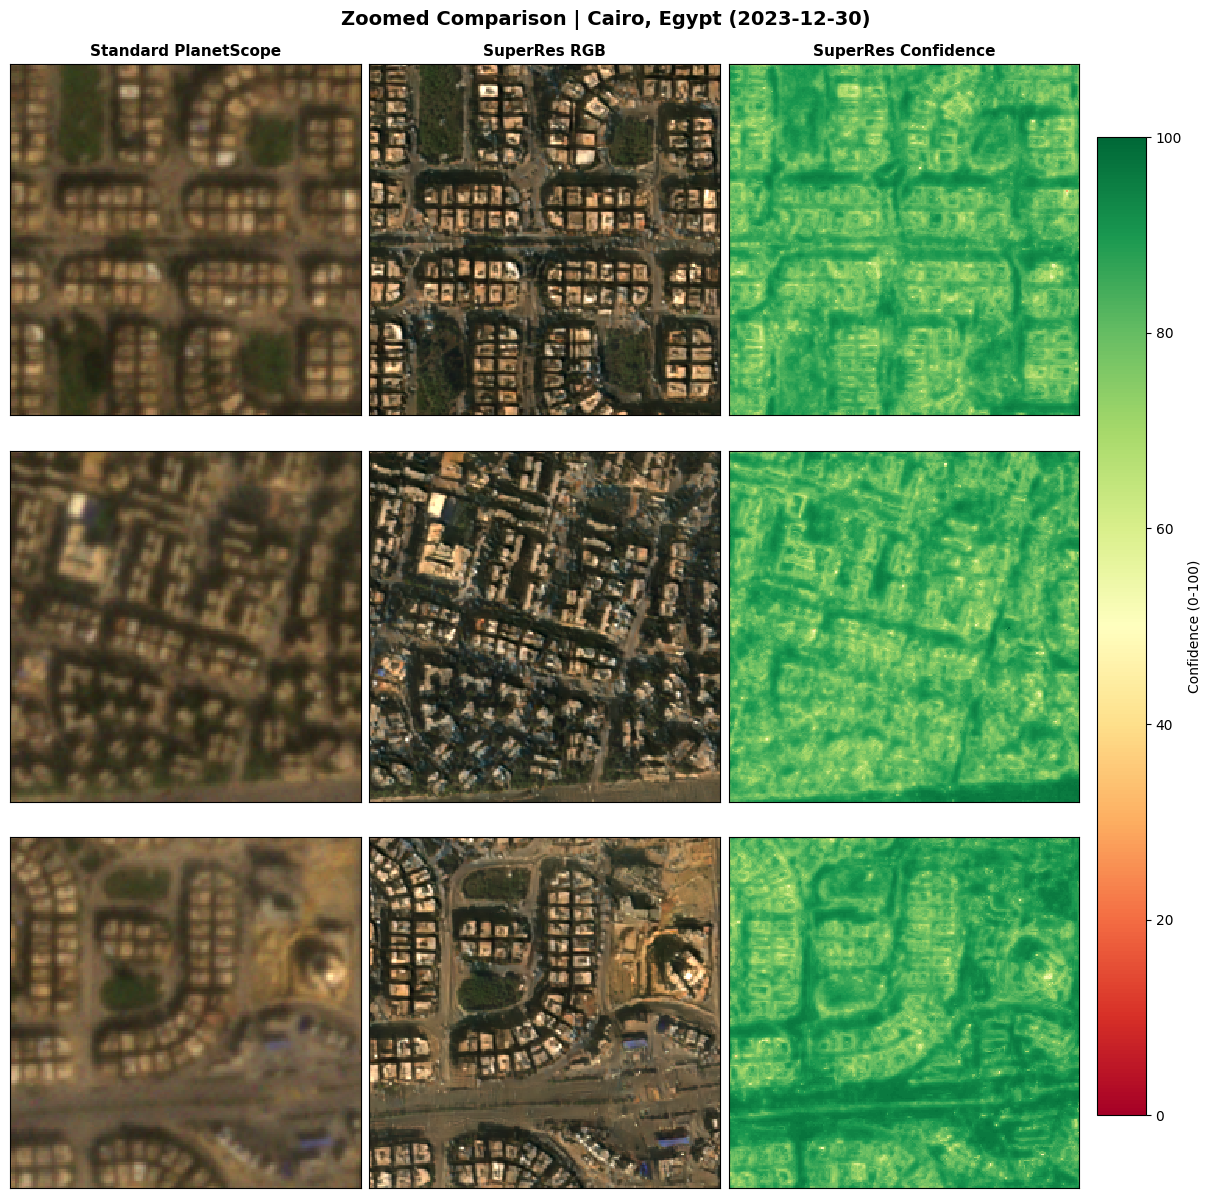

In [10]:
def crop_bottom_left_anchor(arr, crop_h, crop_w, bx, by):
    # (bx, by) in [0, 1]: bottom-left corner of the crop, from raster south-west.
    H, W = arr.shape[0], arr.shape[1]
    crop_h = min(int(crop_h), H)
    crop_w = min(int(crop_w), W)
    col0 = int(round(bx * (W - crop_w)))
    row_bottom = (H - 1) - int(round(by * (H - crop_h)))
    row0 = row_bottom - crop_h + 1
    col0 = max(0, min(col0, W - crop_w))
    row0 = max(0, min(row0, H - crop_h))
    return arr[row0 : row0 + crop_h, col0 : col0 + crop_w]


CROP_PX_STANDARD = (
    150  # edge length on standard grid; SuperRes crop scales for same ground area
)

Hs, Ws = standard_planet_scope.shape[0], standard_planet_scope.shape[1]
super_res_red_band = super_res_planet_scope["red.tif"]
Hr, Wr = super_res_red_band.shape[0], super_res_red_band.shape[1]
crop_h_r = max(1, int(round(CROP_PX_STANDARD * Hr / Hs)))
crop_w_r = max(1, int(round(CROP_PX_STANDARD * Wr / Ws)))

anchors = [(0.0, 0.0), (0.0, 0.75), (0.7, 0.7)]

std_rgb = standard_planet_scope[..., :3]

fig, axes = plt.subplots(3, 3, figsize=(12, 12), layout="constrained")

for j, name in enumerate(
    ["Standard PlanetScope", "SuperRes RGB", "SuperRes Confidence"]
):
    axes[0, j].set_title(name, fontsize=11, fontweight="bold")

for i, (bx, by) in enumerate(anchors):
    s_crop = crop_bottom_left_anchor(
        std_rgb, CROP_PX_STANDARD, CROP_PX_STANDARD, bx, by
    )
    r_crop = crop_bottom_left_anchor(
        super_res_planet_scope_RGB, crop_h_r, crop_w_r, bx, by
    )
    c_crop = crop_bottom_left_anchor(
        super_res_planet_scope[CONFIDENCE_BAND], crop_h_r, crop_w_r, bx, by
    )

    axes[i, 0].imshow(s_crop, origin="upper", interpolation="nearest")
    axes[i, 1].imshow(r_crop, origin="upper", interpolation="nearest")
    im = axes[i, 2].imshow(
        c_crop, origin="upper", interpolation="nearest", cmap="RdYlGn", vmin=0, vmax=100
    )

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    f"Zoomed Comparison | Cairo, Egypt ({DATE})", fontsize=14, fontweight="bold"
)
fig.colorbar(im, ax=axes[:, 2], shrink=0.85, label="Confidence (0-100)")
plt.show()
